# **Modeling Deep Dive**

In this notebook, we'll use the California Housing dataset to explore:

1. Random forest regression
2. Cross-validation
3. Scikit-learn `Pipeline`s
4. Hyperparameters and `GridSearchCV`
5. Evaluating a tuned model on a held-out test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Dataset

The California Housing dataset is a regression dataset. Each observation represents a California district, and the response is the median house value for that district.

We'll keep a test set separate from the beginning. We will use the training data for cross-validation and hyperparameter tuning, and only use the test set at the very end for our final evaluation.

This separation helps prevent the test set from influencing our model-selection decisions.

In [2]:
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
display(X.head())
print("\nTarget:")
display(y.head())

X shape: (20640, 8)
y shape: (20640,)

Features:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Target:


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [3]:
# Create a held-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=107
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")

Training observations: 16,512
Test observations: 4,128


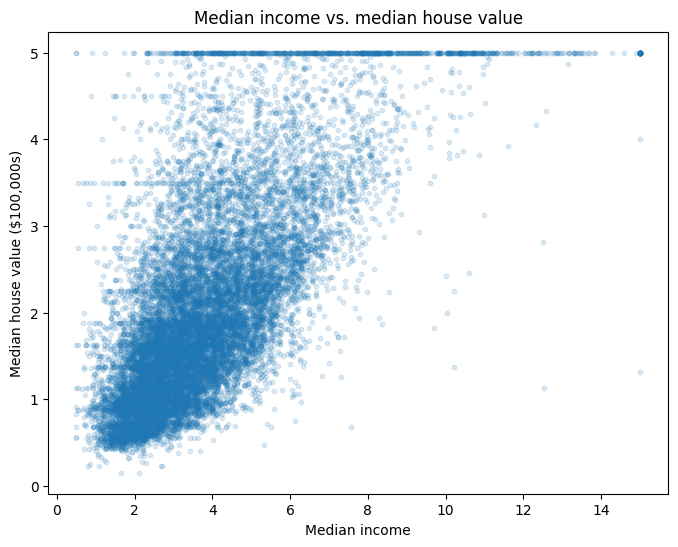

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_train["MedInc"],
    y_train,
    alpha=0.15,
    s=10
)
plt.xlabel("Median income")
plt.ylabel("Median house value ($100,000s)")
plt.title("Median income vs. median house value")
plt.show()

## Random Forest Regression

A random forest builds many decision trees using randomized samples/features and averages their predictions.

For regression, the forest's prediction is based on the predictions from its trees.

A few important random-forest hyperparameters include:

- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_split`: minimum number of observations needed to split a node
- `min_samples_leaf`: minimum number of observations allowed in a leaf
- `max_features`: number/proportion of features considered when looking for a split

Unlike many distance-based or linear models, random forests generally do not require standardized predictors. We will still use a pipeline later because pipelines provide a clean, reusable modeling workflow and become especially useful when preprocessing is needed.

In [5]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=107,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test MAE: ", mean_absolute_error(y_test, y_pred))
print("Test R²:  ", r2_score(y_test, y_pred))

Test RMSE: 0.5226340858263294
Test MAE:  0.33160646195494214
Test R²:   0.799909430309834


## Cross-Validation

Instead of relying on one train/validation split, K-fold cross-validation repeatedly trains and validates the model on different subsets of the training data.

With 5-fold CV:

1. Split the training data into 5 folds.
2. Train on 4 folds and validate on the remaining fold.
3. Repeat until every fold has been used as validation data.
4. Average the validation scores.

We'll use negative mean squared error because scikit-learn's scoring convention treats larger scores as better. Therefore, the values returned by `cross_val_score` will be negative; we can multiply by `-1` to get MSE and then take the square root to get RMSE.

In [6]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=107
)

In [7]:
cv_mse = -cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

cv_rmse = np.sqrt(cv_mse)

print("RMSE for each fold:")
print(cv_rmse)

print(f"\nMean CV RMSE: {cv_rmse.mean():.4f}")
print(f"Std. CV RMSE: {cv_rmse.std():.4f}")

RMSE for each fold:
[0.52777779 0.50351888 0.50705946 0.49319072 0.51092747]

Mean CV RMSE: 0.5085
Std. CV RMSE: 0.0113


## Pipelines

A `Pipeline` chains preprocessing steps and a model into one estimator.

The basic structure is:

```text
data → preprocessing → model
```

For this random forest, scaling is not necessary. However, including a scaler demonstrates the same pipeline structure you would use for models that do require scaling.

An important advantage is that during cross-validation, preprocessing is fit separately inside each training fold. This helps prevent information from the validation fold from leaking into preprocessing.

In [8]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=107,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

pipeline_pred = pipeline.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pipeline_pred)))
print("Test R²:  ", r2_score(y_test, pipeline_pred))

Test RMSE: 0.5225325051869993
Test R²:   0.7999872030892989


## Hyperparameters

A **hyperparameter** is a setting chosen before/during model fitting rather than a parameter directly estimated from the training data.

For our random forest, we'll tune:

| Hyperparameter | Meaning |
|---|---|
| `n_estimators` | Number of trees |
| `max_depth` | Maximum depth of each tree |
| `min_samples_leaf` | Minimum observations in each leaf |

There is a tradeoff:

- More complex trees can capture more structure but may overfit.
- More restrictive trees can reduce variance but may underfit.
- More trees generally make the forest more stable, at the cost of computation.

We will let cross-validation help us compare candidate combinations.

`GridSearchCV` evaluates every combination in a specified parameter grid using cross-validation.

For a pipeline, parameters for a particular step are referenced using:

```text
step_name__parameter_name
```

For example:

```python
"model__max_depth"
```

means the `max_depth` parameter of the pipeline step named `"model"`.

In [14]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(f"\nBest CV RMSE: "
      f"{np.sqrt(-grid_search.best_score_):.4f}")

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}

Best CV RMSE: 0.5085


`cv_results_` contains information about every hyperparameter combination tested.

Let's put the results into a DataFrame and sort by validation RMSE.

In [15]:
results = pd.DataFrame(grid_search.cv_results_)

results["mean_cv_rmse"] = np.sqrt(-results["mean_test_score"])

results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "mean_cv_rmse",
        "std_test_score"
    ]
].sort_values("mean_cv_rmse").head(10)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_cv_rmse,std_test_score
3,200,None,2,0.508548,0.012165
1,200,None,1,0.508585,0.011529
15,200,20,2,0.508757,0.012100
13,200,20,1,0.508871,0.011471
2,100,None,2,0.510244,0.012168
0,100,None,1,0.510368,0.011219
14,100,20,2,0.510463,0.012001
12,100,20,1,0.510525,0.011066
5,200,None,5,0.515538,0.013164
17,200,20,5,0.515566,0.013177


After grid search chooses the hyperparameters using the training data and cross-validation, we can evaluate the resulting model on the test set.

This is the first time we use `X_test` and `y_test` for model evaluation.

In [16]:
best_model = grid_search.best_estimator_

test_pred = best_model.predict(X_test)

test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R²:   {test_r2:.4f}")

Test RMSE: 0.5220
Test MAE:  0.3311
Test R²:   0.8004


## Feature Importance

Random forests provide a feature-importance measure based on how much features contribute to reducing impurity across the trees.

This can be useful for exploration, but feature importance should not automatically be interpreted as a causal effect.

Let's inspect the features with the largest importance values.

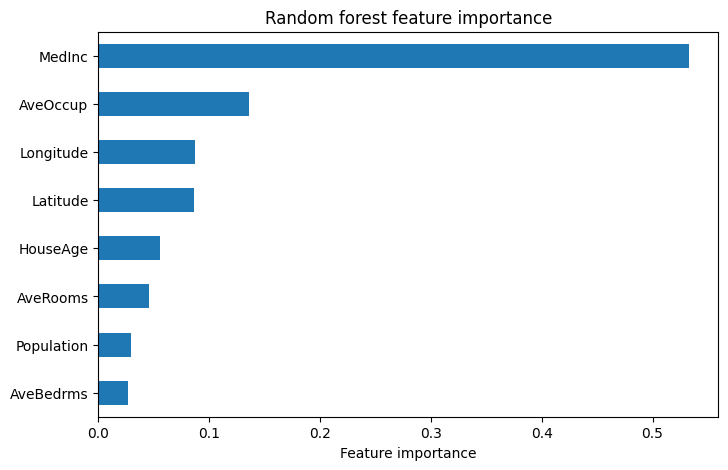

In [17]:
best_rf = best_model.named_steps["model"]

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Random forest feature importance")
plt.show()

## Try it yourself!

Design a pipeline using K-Nearest Neighbors regressor (take a look at Modeling Part 2 if you have forgotten). Include a preprocessing step using `StandardScaler` and use `GridSearchCV` to find the best hyperparameters for your model! How does it compare to our random forest?

In [13]:
# your code here (good luck!!!)
...

Ellipsis